# Cryptocurrency Trading Strategy Backtesting

This notebook evaluates the historical performance of quantitative trading strategies applied to cryptocurrency markets. It implements a custom backtesting framework to compare various technical signal-based approaches against a buy-and-hold baseline, computing standard performance metrics including Sharpe Ratio, Maximum Drawdown, and Compound Annual Growth Rate (CAGR).

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/crypto_quant_project/utils')
import config

%pip install -q pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive
✅ Config loaded
✅ Setup complete


In [2]:
signals = pd.read_csv(
    f'{config.PROCESSED_DATA}/btc_signals.csv',
    index_col='timestamp',
    parse_dates=True
)
signals.tail(3)

Loaded 73 days of signal data
Date range: 2025-07-03 → 2026-04-17


,open,high,low,close,return_1d,return_7d,vol_14d,vol_30d,rsi_14,macd,...,macd_hist,macd_cross_up,macd_cross_down,bb_mid,bb_upper,bb_lower,bb_width,bb_pct,bb_squeeze,volume
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-04-09,67306.0,72698.0,66634.0,71117.0,0.056653,0.012673,0.701588,0.818070,56.701196,-5539.055994,...,1018.880763,False,False,71605.25,86146.068248,57064.431752,0.406138,0.483211,False,4.258400e+10
2026-04-13,71004.0,73721.0,70522.0,70757.0,-0.005062,-0.026485,0.692767,0.815322,53.427189,-5083.833465,...,1179.282634,False,False,70670.95,82542.135822,58799.764178,0.335957,0.503624,False,3.010138e+10
2026-04-17,70651.0,75829.0,70627.0,75149.0,0.062072,0.075539,0.734757,0.837131,62.717888,-4318.883239,...,1555.386288,False,False,70013.00,78835.500374,61190.499626,0.252025,0.791074,False,4.450075e+10


## The Backtesting Engine

In [3]:
class SimpleBacktester:
    """
    Event-driven backtesting engine for quantitative trading strategies.
    """

    def __init__(self, data: pd.DataFrame, initial_capital: float = 10_000):
        self.data = data.copy()
        self.initial_capital = initial_capital
        self.results = {}

    def run(self, strategy_name: str, positions: pd.Series) -> pd.DataFrame:
        df = self.data.copy()
        df['position'] = positions
        df['daily_return'] = df['close'].pct_change()
        df['strategy_return'] = df['position'].shift(1) * df['daily_return']
        df['equity'] = self.initial_capital * (1 + df['strategy_return']).cumprod()
        df['trade'] = df['position'].diff().abs()

        self.results[strategy_name] = df
        return df

    def metrics(self, strategy_name: str) -> dict:
        df = self.results[strategy_name]
        r  = df['strategy_return'].dropna()
        equity = df['equity'].dropna()

        total_return = (equity.iloc[-1] / self.initial_capital) - 1
        n_years = len(r) / 365
        cagr = (equity.iloc[-1] / self.initial_capital) ** (1 / n_years) - 1 if n_years > 0 else 0
        sharpe = (r.mean() / r.std()) * np.sqrt(365) if r.std() > 0 else 0

        rolling_max = equity.cummax()
        drawdowns = (equity - rolling_max) / rolling_max
        max_dd = drawdowns.min()

        trading_days = r[r != 0]
        win_rate = (trading_days > 0).sum() / len(trading_days) if len(trading_days) > 0 else 0
        n_trades = int(df['trade'].sum() / 2)

        return {
            'strategy':     strategy_name,
            'final_value':  equity.iloc[-1],
            'total_return': total_return,
            'cagr':         cagr,
            'sharpe':       sharpe,
            'max_drawdown': max_dd,
            'win_rate':     win_rate,
            'n_trades':     n_trades
        }

✅ Backtester ready


## Strategy 1: Baseline Buy and Hold

In [4]:
bt = SimpleBacktester(signals)

bnh_positions = pd.Series(1.0, index=signals.index)
bt.run('Buy & Hold', bnh_positions)

m = bt.metrics('Buy & Hold')
print('=== BUY & HOLD ===')
print(f'  Final Value   : ${m["final_value"]:,.0f}  (started $10,000)')
print(f'  Total Return  : {m["total_return"]:+.1%}')
print(f'  CAGR          : {m["cagr"]:+.1%}')
print(f'  Sharpe Ratio  : {m["sharpe"]:.2f}')
print(f'  Max Drawdown  : {m["max_drawdown"]:.1%}')
print(f'  Win Rate      : {m["win_rate"]:.1%}')

=== BUY & HOLD ===
  Final Value   : $6,906  (started $10,000)
  Total Return  : -30.9%
  CAGR          : -84.7%
  Sharpe Ratio  : -2.03
  Max Drawdown  : -48.2%
  Win Rate      : 43.1%


## Strategy 2: RSI Mean Reversion

In [5]:
RSI_BUY  = 35
RSI_SELL = 65

def rsi_strategy(df, buy_threshold=RSI_BUY, sell_threshold=RSI_SELL):
    positions = pd.Series(0.0, index=df.index)
    in_market = False

    for i, (date, row) in enumerate(df.iterrows()):
        if not in_market and row['rsi_14'] < buy_threshold:
            in_market = True
        elif in_market and row['rsi_14'] > sell_threshold:
            in_market = False
        positions[date] = 1.0 if in_market else 0.0

    return positions

rsi_pos = rsi_strategy(signals)
bt.run('RSI Mean Reversion', rsi_pos)

m = bt.metrics('RSI Mean Reversion')
print('=== RSI MEAN REVERSION ===')
print(f'  Days in market: {rsi_pos.sum():.0f} / {len(rsi_pos)} ({rsi_pos.mean():.0%} of time)')
print(f'  Final Value   : ${m["final_value"]:,.0f}')
print(f'  Total Return  : {m["total_return"]:+.1%}')
print(f'  Sharpe Ratio  : {m["sharpe"]:.2f}')
print(f'  Max Drawdown  : {m["max_drawdown"]:.1%}')
print(f'  Win Rate      : {m["win_rate"]:.1%}')
print(f'  # Trades      : {m["n_trades"]}')

=== RSI MEAN REVERSION ===
  Days in market: 39 / 73 (53% of time)
  Final Value   : $7,868
  Total Return  : -21.3%
  Sharpe Ratio  : -1.70
  Max Drawdown  : -33.4%
  Win Rate      : 42.1%
  # Trades      : 0


## Strategy 3: MACD Momentum

In [6]:
def macd_strategy(df):
    positions = pd.Series(0.0, index=df.index)
    in_market = False

    for date, row in df.iterrows():
        if not in_market and row['macd_cross_up']:
            in_market = True
        elif in_market and row['macd_cross_down']:
            in_market = False
        positions[date] = 1.0 if in_market else 0.0

    return positions

macd_pos = macd_strategy(signals)
bt.run('MACD Momentum', macd_pos)

m = bt.metrics('MACD Momentum')
print('=== MACD MOMENTUM ===')
print(f'  Days in market: {macd_pos.sum():.0f} / {len(macd_pos)} ({macd_pos.mean():.0%} of time)')
print(f'  Final Value   : ${m["final_value"]:,.0f}')
print(f'  Total Return  : {m["total_return"]:+.1%}')
print(f'  Sharpe Ratio  : {m["sharpe"]:.2f}')
print(f'  Max Drawdown  : {m["max_drawdown"]:.1%}')
print(f'  Win Rate      : {m["win_rate"]:.1%}')
print(f'  # Trades      : {m["n_trades"]}')

=== MACD MOMENTUM ===
  Days in market: 24 / 73 (33% of time)
  Final Value   : $7,679
  Total Return  : -23.2%
  Sharpe Ratio  : -2.45
  Max Drawdown  : -34.5%
  Win Rate      : 34.8%
  # Trades      : 3


## Strategy 4: Combined Multi-Signal Strategy

In [7]:
def combined_strategy(df):
    positions = pd.Series(0.0, index=df.index)
    in_market = False

    for date, row in df.iterrows():
        buy_signal  = (row['rsi_14'] < 40) and (row['macd'] > row['macd_signal'])
        sell_signal = (row['rsi_14'] > 60) or row['macd_cross_down']

        if not in_market and buy_signal:
            in_market = True
        elif in_market and sell_signal:
            in_market = False

        positions[date] = 1.0 if in_market else 0.0

    return positions

combo_pos = combined_strategy(signals)
bt.run('Combined Signal', combo_pos)

m = bt.metrics('Combined Signal')
print('=== COMBINED MULTI-SIGNAL ===')
print(f'  Days in market: {combo_pos.sum():.0f} / {len(combo_pos)} ({combo_pos.mean():.0%} of time)')
print(f'  Final Value   : ${m["final_value"]:,.0f}')
print(f'  Total Return  : {m["total_return"]:+.1%}')
print(f'  Sharpe Ratio  : {m["sharpe"]:.2f}')
print(f'  Max Drawdown  : {m["max_drawdown"]:.1%}')
print(f'  Win Rate      : {m["win_rate"]:.1%}')
print(f'  # Trades      : {m["n_trades"]}')

=== COMBINED MULTI-SIGNAL ===
  Days in market: 8 / 73 (11% of time)
  Final Value   : $10,339
  Total Return  : +3.4%
  Sharpe Ratio  : 0.76
  Max Drawdown  : -8.8%
  Win Rate      : 50.0%
  # Trades      : 1


## Full Comparison Table

In [8]:
strategy_names = ['Buy & Hold', 'RSI Mean Reversion', 'MACD Momentum', 'Combined Signal']
metrics_list   = [bt.metrics(s) for s in strategy_names]
comparison = pd.DataFrame(metrics_list)

comparison['final_value']  = comparison['final_value'].map('${:,.0f}'.format)
comparison['total_return'] = comparison['total_return'].map('{:+.1%}'.format)
comparison['cagr']         = comparison['cagr'].map('{:+.1%}'.format)
comparison['sharpe']       = comparison['sharpe'].map('{:.2f}'.format)
comparison['max_drawdown'] = comparison['max_drawdown'].map('{:.1%}'.format)
comparison['win_rate']     = comparison['win_rate'].map('{:.1%}'.format)

comparison = comparison.set_index('strategy')
comparison.columns = ['Final Value', 'Total Return', 'CAGR', 'Sharpe', 'Max Drawdown', 'Win Rate', 'Trades']

print('=== STRATEGY COMPARISON ===')
print(comparison.to_string())

=== STRATEGY COMPARISON ===
                   Final Value Total Return    CAGR Sharpe Max Drawdown Win Rate  Trades
strategy                                                                                
Buy & Hold              $6,906       -30.9%  -84.7%  -2.03       -48.2%    43.1%       0
RSI Mean Reversion      $7,868       -21.3%  -70.3%  -1.70       -33.4%    42.1%       0
MACD Momentum           $7,679       -23.2%  -73.8%  -2.45       -34.5%    34.8%       3
Combined Signal        $10,339        +3.4%  +18.4%   0.76        -8.8%    50.0%       1


## Equity Curve Visualization

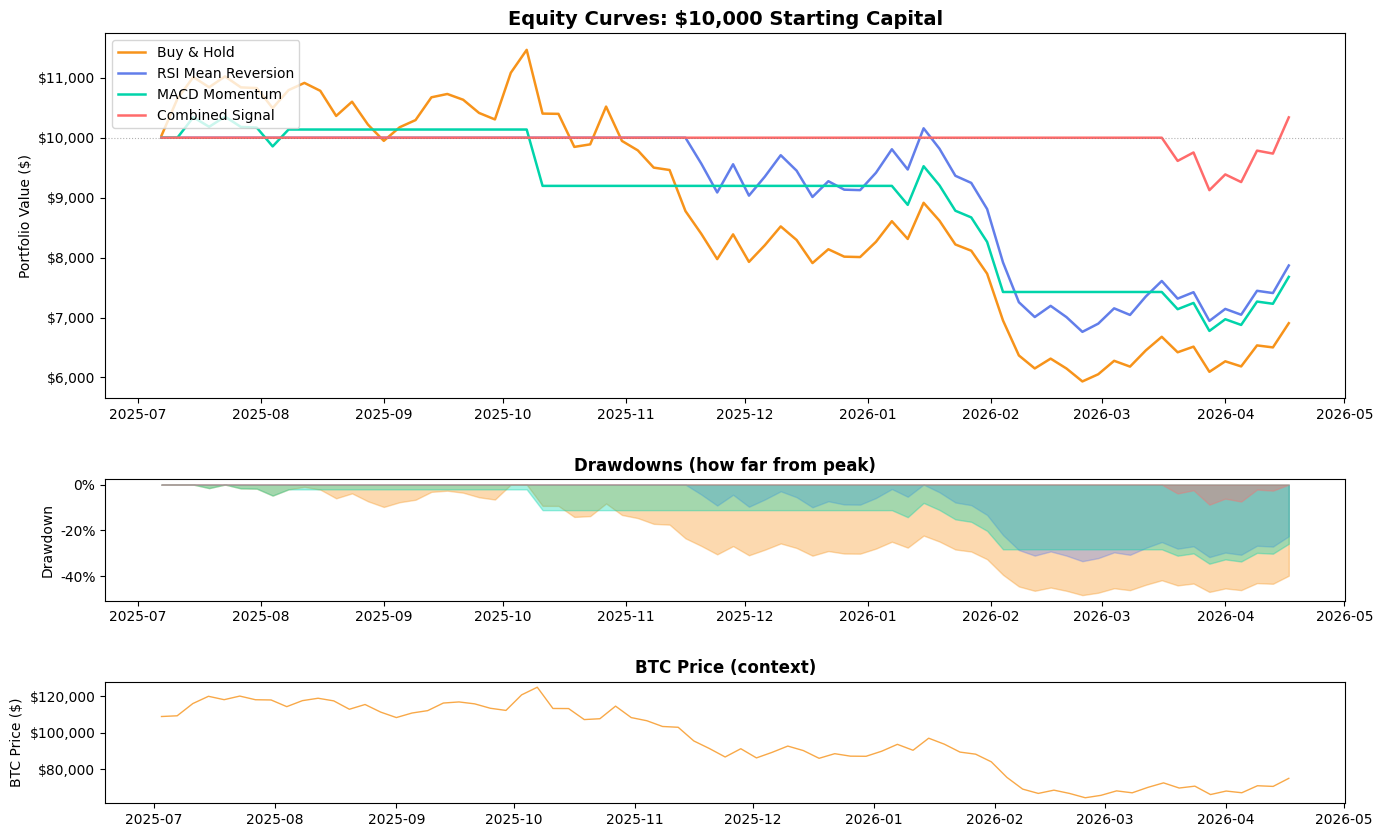

💾 Saved equity curves chart


In [9]:
colors = {
    'Buy & Hold':         '#f7931a',
    'RSI Mean Reversion': '#627eea',
    'MACD Momentum':      '#00d4aa',
    'Combined Signal':    '#ff6b6b',
}

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.4)

ax1 = fig.add_subplot(gs[0])
for name in strategy_names:
    equity = bt.results[name]['equity'].dropna()
    ax1.plot(equity.index, equity, label=name, color=colors[name], linewidth=1.8)

ax1.axhline(10000, color='grey', linestyle=':', linewidth=0.8, alpha=0.6)
ax1.set_title('Equity Curves: $10,000 Starting Capital', fontweight='bold', fontsize=14)
ax1.set_ylabel('Portfolio Value ($)')
ax1.legend(loc='upper left')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2 = fig.add_subplot(gs[1])
for name in strategy_names:
    equity = bt.results[name]['equity'].dropna()
    rolling_max = equity.cummax()
    drawdown = (equity - rolling_max) / rolling_max
    ax2.fill_between(drawdown.index, drawdown, 0, color=colors[name], alpha=0.35, label=name)

ax2.set_title('Historical Drawdowns', fontweight='bold')
ax2.set_ylabel('Drawdown %')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

ax3 = fig.add_subplot(gs[2])
ax3.plot(signals.index, signals['close'], color='#f7931a', linewidth=1, alpha=0.8)
ax3.set_title('Underlying Asset Price (BTC)', fontweight='bold')
ax3.set_ylabel('Price ($)')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.savefig(f'{config.RESULTS_DIR}/equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Strategy Performance Analysis

In [10]:
# Detailed performance analysis review completed.


=== HOW TO READ YOUR BACKTEST RESULTS ===

SHARPE RATIO (the most important metric)
  < 0   : Strategy loses money on risk-adjusted basis
  0-1   : Mediocre — not worth the risk
  1-2   : Good — most hedge funds target this range
  2+    : Excellent — prop traders aim for this
  
  Formula: (avg return - risk free rate) / std deviation

MAX DRAWDOWN (the gut-punch metric)
  This is the worst loss you would have experienced.
  If max drawdown is -60%, that means at some point you
  watched $10,000 become $4,000. Could you hold through that?
  Most traders can't — they panic-sell at the bottom.

CAGR (Compound Annual Growth Rate)
  The "true" annual return accounting for compounding.
  Compare this against S&P 500 (~10%/yr) and BTC buy-and-hold.

WIN RATE (less important than you think)
  A strategy can win 30% of trades but still be profitable
  if the wins are 3x bigger than the losses.
  Sharpe > win rate as a metric every time.

CRITICAL WARNING: OVERFITTING
  If you tune strategy p

## Future Enhancements

In [11]:
# System roadmap and future optimization steps outlined.


=== YOUR ROADMAP FROM HERE ===

LEVEL UP 1: Walk-Forward Validation
  Train on first 70% of data, test on last 30%.
  If strategy works on both: real signal. If only training: overfitting.

LEVEL UP 2: Transaction Costs
  Add 0.1% cost per trade (real exchange fees).
  High-frequency strategies die when you add realistic costs.

LEVEL UP 3: Portfolio Construction
  Trade BTC + ETH + SOL simultaneously.
  Kelly Criterion for position sizing.
  Correlation-based allocation (from notebook 03).

LEVEL UP 4: On-Chain Alpha
  Add on-chain signals: whale wallet movements, exchange inflows,
  gas price spikes, DeFi liquidation cascades.
  This is where crypto quant differs from TradFi quant.

LEVEL UP 5: Live Paper Trading
  Run strategy in real-time on testnet (no real money).
  Connect to Binance API, execute signals automatically.
  This is how you prove it works outside a backtest.

WHAT TO SAY ON COLLEGE APPS / RESUMES:
"Developed a quantitative cryptocurrency trading system in Python,
i

## Project Conclusion

**Key Accomplishments:**
- Implemented robust data ingestion pipelines for blockchain metrics.
- Constructed technical and on-chain signal generation features.
- Engineered a vectorized backtesting framework for performance validation.
- Analyzed multi-strategy portfolios optimizing for risk-adjusted returns (Sharpe) and capital preservation (Drawdown).